In [1]:
import numpy as np
from scipy.interpolate import lagrange, CubicSpline
import matplotlib.pyplot as plt

### Zadanie 1

In [2]:
h = [0, 3, 6]
d = [1.225, 0.905, 0.652]

In [3]:
print(lagrange(h, d))

          2
0.003722 x - 0.1178 x + 1.225


In [4]:
def Lagrange_interpolation(x, X, Y):

    if len(X) != len(Y):
        raise "Number of values doesn't match"
    
    n = len(X)
    W = 0
    for i in range(n):
        phi = 1.0
        for j in range(n):
            if j != i:
                phi *= (x - X[j]) / (X[i] - X[j])
        W += Y[i] * phi
    
    return W

In [5]:
def Newton_polynomial(X, Y):
    n = len(X)-1
    W = np.copy(Y)
    for i in range(1,n+1):
        for j in range(n,i-1,-1):
            W[j]=(W[j]-W[j-1])/(X[j]-X[j-i])

    a = np.copy(W)
    for i in range(n):
        for j in range(n-1,i-1,-1):
            a[j]=a[j]-X[j-i]*a[j+1]

    p = np.polynomial.Polynomial(a)
    return p

print(Newton_polynomial(h, d))

1.225 - 0.11783333 x + 0.00372222 x**2


### Zadanie 2 i 3

In [6]:
Re = [0.2, 2, 20, 200, 2000, 20000]
cd = [103, 13.9, 2.72, 0.8, 0.401, 0.433]

In [7]:
cs = CubicSpline(Re, cd, bc_type="natural")
print(cs(5), Lagrange_interpolation(5, Re, cd))
print(cs(50), Lagrange_interpolation(50, Re, cd))
print(cs(5000), Lagrange_interpolation(5000, Re, cd))

-88.94021032085111 -96.10046207185482
458.2884212067052 2581.144117967352
9920.95571242435 1658455172.0855002


Używanie funkcji sklejanych lepsze dla większych ilości n punktów.

### Zadanie 4

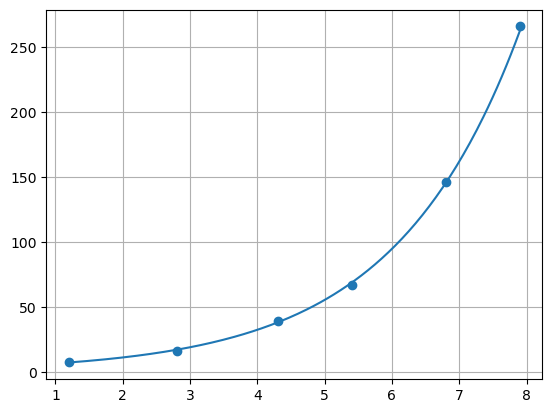

In [8]:
x = np.array([1.2, 2.8, 4.3, 5.4, 6.8, 7.9])
y = np.array([7.5, 16.1, 38.9, 67.0, 146.6, 266.2])

Y = np.log(y)
A = np.column_stack([np.ones_like(x), x]) 

alpha, b = np.linalg.lstsq(A, Y, rcond=None)[0]
a = np.exp(alpha)

xx = np.linspace(x.min(), x.max(), 200)
yy = a * np.exp(b * xx)

plt.scatter(x, y)
plt.plot(xx, yy)
plt.grid(True)
plt.show()

### Zadanie 5

In [9]:
T = [0, 21.1, 37.8, 54.4, 71.1, 87.8, 100]
mi = [1.79, 1.13, 0.696, 0.519, 0.338, 0.321, 0.296]

In [10]:
p = Newton_polynomial([T[0], T[2], T[4], T[6]], [mi[0], mi[2], mi[4], mi[6]])
print(p)
print(f"T = 10*:{p(10)}, T = 30*:{p(30)}, T = 60*:{p(60)}, T = 90*:{p(90)}")

1.79 - 0.04147189 x + 0.00037169 x**2 - (1.06374686e-06) x**3
T = 10*:1.4113866765932497, T = 30*:0.8516462801678659, T = 60*:0.41001409410661793, T = 90*:0.29277645050802104


### Zadanie 6

<function f_lin at 0x000001F24CC48C20> <function f_quad at 0x000001F24CC48B80>


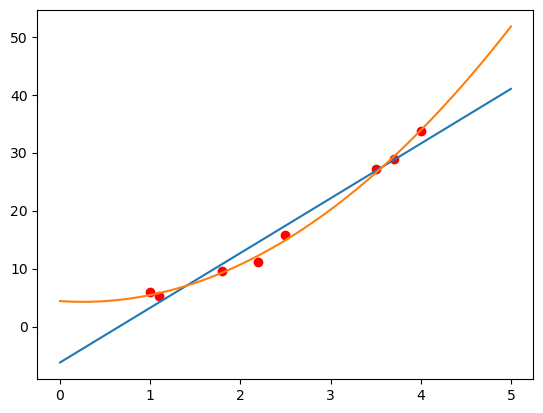

In [11]:
x = [1.0, 2.5, 3.5, 4.0, 1.1, 1.8, 2.2, 3.7]
y = [6.008, 15.722, 27.13, 33.772, 5.257, 9.549, 11.098, 28.828]

def f_lin(x_value):
    f = np.polyfit(x, y, 1)
    return np.polyval(f, x_value)

def f_quad(x_value):
    f = np.polyfit(x, y, 2)
    return np.polyval(f, x_value)

x_arg = np.linspace(0, 5, 100)
print(f_lin, f_quad)
plt.scatter(x, y, color='red')
plt.plot(x_arg, f_lin(x_arg))
plt.plot(x_arg, f_quad(x_arg))

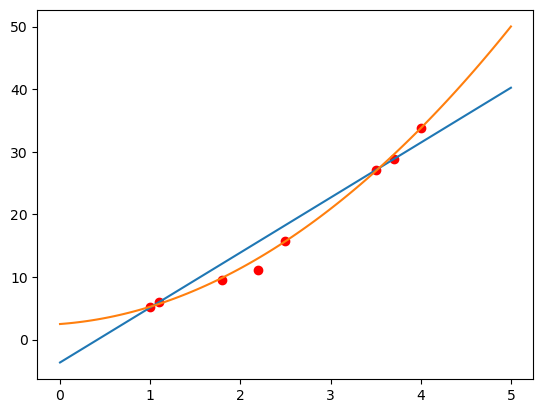

In [13]:
x, y = sorted(x), sorted(y)

k = Newton_polynomial([x[1], x[6]], [y[1], y[6]])
plt.plot(x_arg, k(x_arg))

p = Newton_polynomial([x[0], x[4], x[7]], [y[0], y[4], y[7]])
plt.plot(x_arg, p(x_arg))

plt.scatter(x, y, color='red')

Lepsza jest aproksymacja wielomianowa